# Gradient Boosting Regression on the Diabetes Dataset

This notebook demonstrates the `GradientBoostingRegressor` implemented in the `jiayi_ml` package.

The goal is to predict diabetes disease progression using baseline clinical measurements.

This example emphasizes:

1. Supervised regression.
2. Additive ensemble learning.
3. Residual fitting.
4. Squared-error gradient boosting.
5. Learning rate effects.
6. Number of estimators effects.
7. Training loss interpretation.
8. Comparison with simpler regression baselines.


## 1. Problem Statement

The Diabetes dataset is a supervised regression dataset.

Each observation contains baseline clinical measurements for one patient, and the target is a quantitative measure of disease progression one year after baseline.

The prediction task is:

> Given baseline clinical measurements, predict the continuous disease progression score.

Gradient boosting is appropriate for this example because it builds an additive model sequentially. Each new tree is fit to the residual errors left by the previous ensemble.

This notebook is an educational machine learning example. It should not be interpreted as a clinical prediction tool.


## Modeling Hypothesis

Because the Diabetes dataset has a continuous outcome and potentially nonlinear relationships among clinical measurements, gradient boosting may improve over a simple linear baseline by fitting residual structure in stages.

The main hypothesis is:

> A gradient boosting regressor will reduce training error as more trees are added, and it may improve test performance if the residual patterns contain useful nonlinear signal.

However, because the dataset is small and the outcome is noisy, gradient boosting may also overfit if the ensemble becomes too complex. Therefore, test-set performance should be interpreted together with the training loss curve and hyperparameter sensitivity.


In [1]:
from pathlib import Path
import sys

# Make the local package importable whether the notebook is run from the
# project root or from inside the examples directory.
current_path = Path.cwd().resolve()
for candidate in [current_path, *current_path.parents]:
    if (candidate / "src" / "jiayi_ml").exists():
        sys.path.insert(0, str(candidate / "src"))
        PROJECT_ROOT = candidate
        break

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split

from jiayi_ml.preprocessing import StandardScaler
from jiayi_ml.supervised import (
    GradientBoostingRegressor,
    LinearRegression,
    RidgeRegression,
    DecisionTreeRegressor,
)
from jiayi_ml.metrics import (
    mean_squared_error,
    root_mean_squared_error,
    mean_absolute_error,
    r2_score,
)

np.random.seed(438)
pd.set_option("display.precision", 4)


## 2. Load the Dataset

The dataset is loaded from `sklearn.datasets.load_diabetes`, so the notebook is reproducible without external files.

The dataset contains 10 numeric baseline variables and a continuous disease progression target.


In [2]:
data = load_diabetes(as_frame=True)

X = data.data
y = data.target
feature_names = X.columns.tolist()

df = X.copy()
df["target"] = y

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)
print("Feature names:", feature_names)

df.head()


Feature matrix shape: (442, 10)
Target shape: (442,)
Feature names: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.0381,0.0507,0.0617,0.0219,-0.0442,-0.0348,-0.0434,-0.0026,0.0199,-0.0176,151.0
1,-0.0019,-0.0446,-0.0515,-0.0263,-0.0084,-0.0192,0.0744,-0.0395,-0.0683,-0.0922,75.0
2,0.0853,0.0507,0.0445,-0.0057,-0.0456,-0.0342,-0.0324,-0.0026,0.0029,-0.0259,141.0
3,-0.0891,-0.0446,-0.0116,-0.0367,0.0122,0.0250,-0.0360,0.0343,0.0227,-0.0094,206.0
4,0.0054,-0.0446,-0.0364,0.0219,0.0039,0.0156,0.0081,-0.0026,-0.0320,-0.0466,135.0


## 3. Exploratory Data Analysis

Before fitting gradient boosting, we inspect:

- Missing values
- Feature summary statistics
- Target distribution
- Feature-target correlations

Gradient boosting can model nonlinear and threshold-like structure, but exploratory analysis is still useful for understanding the prediction problem.


In [3]:
missing_values = df.isna().sum()

print("Total missing values:", int(missing_values.sum()))

summary = df.describe().T
summary


Total missing values: 0


,count,mean,std,min,25%,50%,75%,max
age,442.0,-2.5118e-19,0.0476,-0.1072,-0.0373,0.0054,0.0381,0.1107
sex,442.0,1.2308e-17,0.0476,-0.0446,-0.0446,-0.0446,0.0507,0.0507
bmi,442.0,-2.2456e-16,0.0476,-0.0903,-0.0342,-0.0073,0.0312,0.1706
bp,442.0,-4.7976e-17,0.0476,-0.1124,-0.0367,-0.0057,0.0356,0.1320
s1,442.0,-1.3815e-17,0.0476,-0.1268,-0.0342,-0.0043,0.0284,0.1539
s2,442.0,3.9184e-17,0.0476,-0.1156,-0.0304,-0.0038,0.0298,0.1988
s3,442.0,-5.7772e-18,0.0476,-0.1023,-0.0351,-0.0066,0.0293,0.1812
s4,442.0,-9.0425e-18,0.0476,-0.0764,-0.0395,-0.0026,0.0343,0.1852
s5,442.0,9.2686e-17,0.0476,-0.1261,-0.0332,-0.0019,0.0324,0.1336
s6,442.0,1.1303e-17,0.0476,-0.1378,-0.0332,-0.0011,0.0279,0.1356


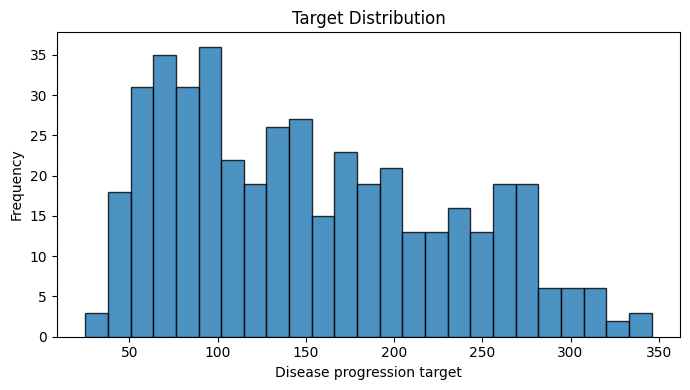

In [4]:
plt.figure(figsize=(7, 4))
plt.hist(y, bins=25, edgecolor="k", alpha=0.8)
plt.xlabel("Disease progression target")
plt.ylabel("Frequency")
plt.title("Target Distribution")
plt.tight_layout()
plt.show()


In [5]:
correlations = df.corr(numeric_only=True)["target"].drop("target")
correlations_sorted = correlations.reindex(
    correlations.abs().sort_values(ascending=False).index
)

correlations_df = correlations_sorted.to_frame(name="correlation_with_target")
correlations_df


,correlation_with_target
bmi,0.5865
s5,0.5659
bp,0.4415
s4,0.4305
s3,-0.3948
s6,0.3825
s1,0.2120
age,0.1879
s2,0.1741
sex,0.0431


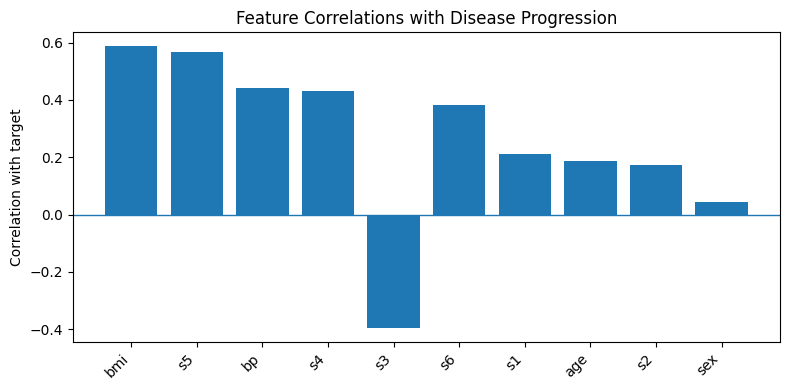

In [6]:
plt.figure(figsize=(8, 4))
plt.bar(correlations_sorted.index, correlations_sorted.values)
plt.axhline(0, linewidth=1)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Correlation with target")
plt.title("Feature Correlations with Disease Progression")
plt.tight_layout()
plt.show()


The correlations show which individual features have the strongest linear association with disease progression. Gradient boosting is not limited to purely linear associations, but these correlations provide a useful baseline understanding of the data.


## 4. Train/Test Split and Preprocessing

The data is split into training and test sets.

Tree-based models do not require feature standardization in the same way that linear models or distance-based models do. However, this notebook also fits linear baselines, so standardized features are used for the baseline models.

The gradient boosting model is fit on the original feature scale. This is acceptable because regression trees split features using threshold rules.


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X.values,
    y.values,
    test_size=0.25,
    random_state=438,
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)


Training set shape: (331, 10)
Test set shape: (111, 10)


## 5. Fit Gradient Boosting Regressor

The custom `GradientBoostingRegressor` starts with a constant prediction equal to the training target mean.

Then it repeatedly:

1. Computes residuals.
2. Fits a shallow regression tree to the residuals.
3. Adds the tree prediction to the ensemble after multiplying by the learning rate.

This implementation uses squared-error loss.


In [8]:
gb_model = GradientBoostingRegressor(
    n_estimators=50,
    learning_rate=0.05,
    max_depth=2,
    min_samples_split=2,
    min_samples_leaf=3,
)

gb_model.fit(X_train, y_train)

print("Initial prediction:", gb_model.init_)
print("Number of fitted estimators:", len(gb_model.estimators_))
print("Final training MSE:", gb_model.train_loss_[-1])


Initial prediction: 150.13897280966768
Number of fitted estimators: 50
Final training MSE: 2426.0994912862348


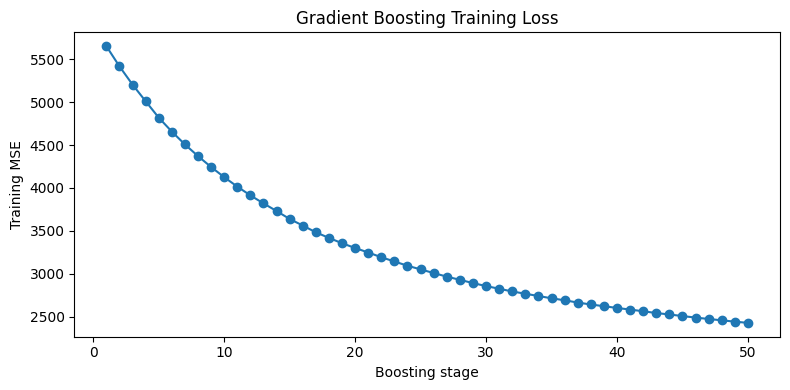

In [9]:
plt.figure(figsize=(8, 4))
plt.plot(np.arange(1, len(gb_model.train_loss_) + 1), gb_model.train_loss_, marker="o")
plt.xlabel("Boosting stage")
plt.ylabel("Training MSE")
plt.title("Gradient Boosting Training Loss")
plt.tight_layout()
plt.show()


The training loss should generally decrease as more trees are added, because each tree is fit to the remaining residual error. A decreasing training loss confirms that the ensemble is fitting the training data progressively.

However, lower training loss does not automatically imply better generalization. Test-set performance must be evaluated separately.


## 6. Test-Set Evaluation

The model is evaluated on held-out test data using:

- Mean squared error
- Root mean squared error
- Mean absolute error
- R-squared

R-squared is useful for interpretation, but it should be treated cautiously on small datasets.


In [10]:
def regression_metrics(y_true, y_pred):
    return {
        "MSE": mean_squared_error(y_true, y_pred),
        "RMSE": root_mean_squared_error(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred),
    }


gb_train_pred = gb_model.predict(X_train)
gb_test_pred = gb_model.predict(X_test)

gb_results = pd.DataFrame(
    {
        "train": regression_metrics(y_train, gb_train_pred),
        "test": regression_metrics(y_test, gb_test_pred),
    }
)

gb_results


,train,test
MSE,2426.0995,3386.1558
RMSE,49.2555,58.1907
MAE,41.2072,46.9772
R2,0.5897,0.4295


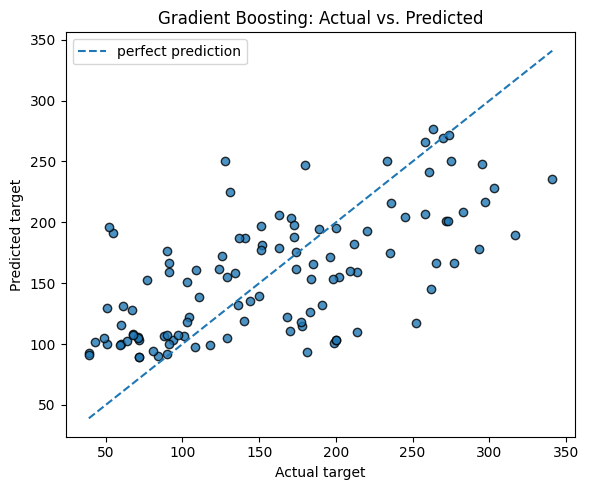

In [11]:
plt.figure(figsize=(6, 5))
plt.scatter(y_test, gb_test_pred, alpha=0.8, edgecolors="k")
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--",
    label="perfect prediction",
)
plt.xlabel("Actual target")
plt.ylabel("Predicted target")
plt.title("Gradient Boosting: Actual vs. Predicted")
plt.legend()
plt.tight_layout()
plt.show()


The actual-versus-predicted plot shows how closely the gradient boosting predictions match the held-out target values. Points close to the dashed diagonal line indicate better predictions.

Because the Diabetes dataset is small and noisy, substantial prediction error is expected even for flexible models.


## 7. Comparison with Baseline Models

Gradient boosting is compared with:

- Linear regression
- Ridge regression
- A single decision tree regressor

The linear models use standardized features. The decision tree and gradient boosting models use the original feature scale.


In [12]:
baseline_models = {
    "Linear Regression": (LinearRegression(), X_train_scaled, X_test_scaled),
    "Ridge Regression": (RidgeRegression(alpha=1.0), X_train_scaled, X_test_scaled),
    "Decision Tree": (
        DecisionTreeRegressor(max_depth=3, min_samples_split=2),
        X_train,
        X_test,
    ),
    "Gradient Boosting": (gb_model, X_train, X_test),
}

comparison_rows = []

for model_name, (model, Xtr, Xte) in baseline_models.items():
    if model_name != "Gradient Boosting":
        model.fit(Xtr, y_train)
    
    train_pred = model.predict(Xtr)
    test_pred = model.predict(Xte)
    
    row = {
        "model": model_name,
        "train_RMSE": root_mean_squared_error(y_train, train_pred),
        "test_RMSE": root_mean_squared_error(y_test, test_pred),
        "train_R2": r2_score(y_train, train_pred),
        "test_R2": r2_score(y_test, test_pred),
    }
    comparison_rows.append(row)

comparison_df = pd.DataFrame(comparison_rows).sort_values("test_RMSE")
comparison_df


,model,train_RMSE,test_RMSE,train_R2,test_R2
0,Linear Regression,52.9419,56.1724,0.5259,0.4684
1,Ridge Regression,52.9491,56.2744,0.5258,0.4664
3,Gradient Boosting,49.2555,58.1907,0.5897,0.4295
2,Decision Tree,52.4859,64.1566,0.5341,0.3065


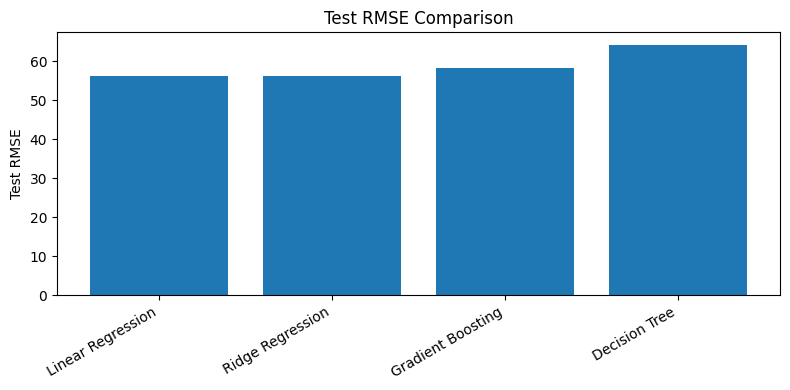

In [13]:
plt.figure(figsize=(8, 4))
plt.bar(comparison_df["model"], comparison_df["test_RMSE"])
plt.xticks(rotation=30, ha="right")
plt.ylabel("Test RMSE")
plt.title("Test RMSE Comparison")
plt.tight_layout()
plt.show()


The comparison table should be interpreted empirically rather than assumed in advance. Gradient boosting often improves over a single tree by combining many weak learners, but it does not always outperform simpler linear models on small tabular datasets.

In this train/test split, Gradient Boosting improves over the single Decision Tree but does not outperform the Linear Regression or Ridge Regression baselines on the test set.

Gradient Boosting achieves lower training RMSE than the linear models, but its test RMSE is higher. This suggests that the boosted ensemble is fitting additional training-set residual structure, but that extra flexibility does not translate into better generalization for this particular split.

This result is useful because it shows that a more flexible ensemble model is not automatically better on a small and noisy regression dataset.


## 8. Number of Estimators Sensitivity

The number of boosting stages controls ensemble complexity.

Too few trees may underfit because the ensemble cannot capture enough residual structure. Too many trees may overfit, especially when the learning rate is not small enough.


In [14]:
estimator_values = [1, 5, 10, 25, 50, 100]
estimator_results = []

for n_estimators in estimator_values:
    model = GradientBoostingRegressor(
        n_estimators=n_estimators,
        learning_rate=0.05,
        max_depth=2,
        min_samples_leaf=3,
    )
    model.fit(X_train, y_train)
    
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    
    estimator_results.append(
        {
            "n_estimators": n_estimators,
            "train_RMSE": root_mean_squared_error(y_train, train_pred),
            "test_RMSE": root_mean_squared_error(y_test, test_pred),
            "train_R2": r2_score(y_train, train_pred),
            "test_R2": r2_score(y_test, test_pred),
        }
    )

estimator_results_df = pd.DataFrame(estimator_results)
estimator_results_df


,n_estimators,train_RMSE,test_RMSE,train_R2,test_R2
0,1,75.1896,75.8447,0.0438,0.0308
1,5,69.4245,70.6665,0.1848,0.1586
2,10,64.2315,66.1401,0.3022,0.2629
3,25,55.2288,60.1393,0.4841,0.3906
4,50,49.2555,58.1907,0.5897,0.4295
5,100,44.2426,59.3530,0.6689,0.4064


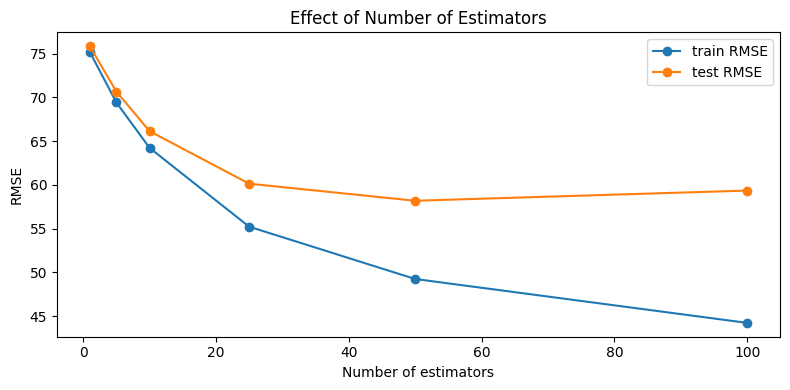

In [15]:
plt.figure(figsize=(8, 4))
plt.plot(
    estimator_results_df["n_estimators"],
    estimator_results_df["train_RMSE"],
    marker="o",
    label="train RMSE",
)
plt.plot(
    estimator_results_df["n_estimators"],
    estimator_results_df["test_RMSE"],
    marker="o",
    label="test RMSE",
)
plt.xlabel("Number of estimators")
plt.ylabel("RMSE")
plt.title("Effect of Number of Estimators")
plt.legend()
plt.tight_layout()
plt.show()


The estimator sensitivity results show that adding trees initially improves both training and test performance. Test RMSE decreases from 75.84 with one estimator to 58.19 with 50 estimators.

However, increasing the ensemble to 100 estimators lowers the training RMSE further but increases the test RMSE. This suggests mild overfitting: the model continues fitting training residuals, but the additional trees no longer improve generalization on the held-out test set.

This supports the need for validation-based model selection or early stopping in gradient boosting.


## 9. Learning Rate Sensitivity

The learning rate controls how much each tree contributes to the ensemble.

Smaller learning rates usually require more trees but can produce smoother, more stable learning. Larger learning rates fit faster but may overfit or become less stable.


In [16]:
learning_rates = [0.01, 0.05, 0.1, 0.2]
learning_rate_results = []

for learning_rate in learning_rates:
    model = GradientBoostingRegressor(
        n_estimators=50,
        learning_rate=learning_rate,
        max_depth=2,
        min_samples_leaf=3,
    )
    model.fit(X_train, y_train)
    
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    
    learning_rate_results.append(
        {
            "learning_rate": learning_rate,
            "train_RMSE": root_mean_squared_error(y_train, train_pred),
            "test_RMSE": root_mean_squared_error(y_test, test_pred),
            "train_R2": r2_score(y_train, train_pred),
            "test_R2": r2_score(y_test, test_pred),
        }
    )

learning_rate_results_df = pd.DataFrame(learning_rate_results)
learning_rate_results_df


,learning_rate,train_RMSE,test_RMSE,train_R2,test_R2
0,0.01,64.3776,66.1070,0.2990,0.2637
1,0.05,49.2555,58.1907,0.5897,0.4295
2,0.10,44.0236,59.4465,0.6722,0.4046
3,0.20,38.4432,61.6746,0.7500,0.3591


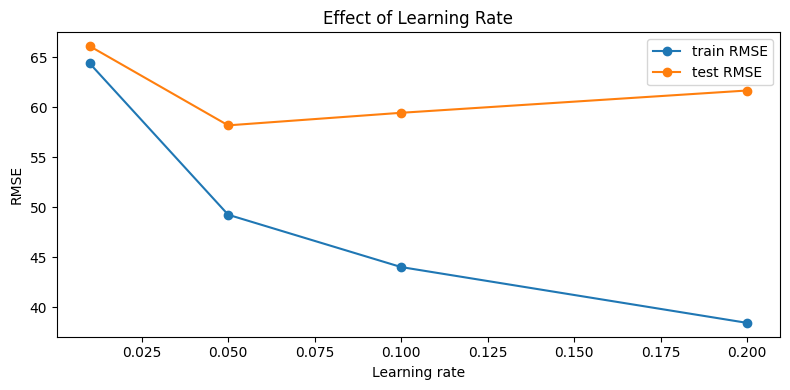

In [17]:
plt.figure(figsize=(8, 4))
plt.plot(
    learning_rate_results_df["learning_rate"],
    learning_rate_results_df["train_RMSE"],
    marker="o",
    label="train RMSE",
)
plt.plot(
    learning_rate_results_df["learning_rate"],
    learning_rate_results_df["test_RMSE"],
    marker="o",
    label="test RMSE",
)
plt.xlabel("Learning rate")
plt.ylabel("RMSE")
plt.title("Effect of Learning Rate")
plt.legend()
plt.tight_layout()
plt.show()


The learning rate sensitivity results show that the smallest learning rate, 0.01, underfits with only 50 estimators because both training and test RMSE remain relatively high.

A learning rate of 0.05 gives the best test RMSE in this small grid. Larger learning rates, such as 0.10 and 0.20, reduce training RMSE more aggressively but worsen test RMSE. This suggests that larger learning rates fit the training data more strongly without improving generalization.

The best learning rate should be selected using validation or cross-validation rather than the test set.


## 10. Staged Test Performance

The `staged_predict` method allows us to inspect how test performance changes after each boosting stage.

This helps diagnose whether adding more trees continues to improve generalization or mainly improves training fit.


In [18]:
stage_rows = []

for stage_index, staged_pred in enumerate(gb_model.staged_predict(X_test), start=1):
    stage_rows.append(
        {
            "stage": stage_index,
            "test_RMSE": root_mean_squared_error(y_test, staged_pred),
            "test_R2": r2_score(y_test, staged_pred),
        }
    )

stage_df = pd.DataFrame(stage_rows)
stage_df.head()


,stage,test_RMSE,test_R2
0,1,75.8447,0.0308
1,2,74.3873,0.0677
2,3,73.0489,0.1009
3,4,71.8004,0.1314
4,5,70.6665,0.1586


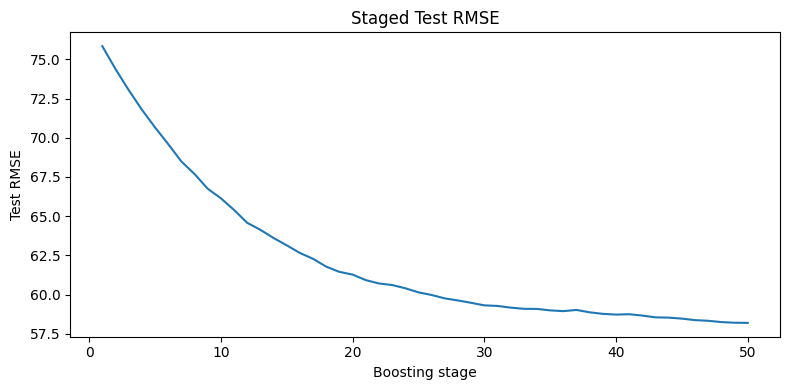

In [19]:
plt.figure(figsize=(8, 4))
plt.plot(stage_df["stage"], stage_df["test_RMSE"])
plt.xlabel("Boosting stage")
plt.ylabel("Test RMSE")
plt.title("Staged Test RMSE")
plt.tight_layout()
plt.show()


The staged test curve is useful because gradient boosting is sequential. If test RMSE decreases and then increases, that may indicate overfitting after too many stages.

This notebook uses a simple train/test split, so the curve should be interpreted as exploratory rather than as a final model-selection procedure.


## 11. Interpretation

Gradient boosting reduces training error by fitting a sequence of shallow trees to residuals. This can capture nonlinear patterns that linear models may miss.

However, on small biomedical-style tabular datasets, a more flexible model does not automatically guarantee better test performance. If the linear baseline performs similarly or better, that suggests the dataset may not contain enough stable nonlinear signal for gradient boosting to exploit under this split.

The main value of this notebook is to show how gradient boosting learns sequentially and how hyperparameters such as number of estimators and learning rate affect the bias-variance trade-off.


## 12. Limitations

This analysis has several limitations:

1. The dataset is small.
2. The result is based on one train/test split.
3. Hyperparameter tuning is limited.
4. The custom implementation uses squared-error regression only.
5. The custom implementation is not optimized for large datasets.
6. The test set is used for demonstration, not for formal model selection.
7. Clinical generalization would require external validation.

A stronger analysis could use cross-validation, validation curves, early stopping, and comparison with optimized library implementations.


## 13. Conclusion

This notebook demonstrated gradient boosting regression using the custom `GradientBoostingRegressor` implementation from `jiayi_ml`.

Key takeaways:

- Gradient boosting builds an additive ensemble sequentially.
- Each tree is fit to the residuals of the current ensemble.
- Training loss generally decreases as more trees are added.
- Learning rate and number of estimators control model complexity.
- Gradient boosting can model nonlinear structure, but it may overfit small datasets.
- Test-set evaluation is necessary because training loss alone does not measure generalization.

In this split, Gradient Boosting improves over a single decision tree but does not outperform the simpler linear baselines, illustrating that model flexibility must be evaluated empirically.
